# STEP 1: Problem Statement-
- Task 1:- Prepare a complete data analysis report on the concrete data.

- Task 2:- Create a machine learning model which can predict the future strength of a concrete mix, based on its constituents’ composition and also the age of the mix.


# STEP 2: Import Basic Libraries-

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

from scipy.stats import randint

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="Pandas requires version")

# STEP 3: Load Dataset-

In [2]:
data = pd.read_csv("concrete.csv")
data

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


# STEP 4: Domain Analysis-

- Concrete strength depends mainly on the **quantity and quality of binding materials** (cement + supplementary materials like slag and ash).
- **Water–cement ratio** is a critical factor — higher water reduces strength due to increased porosity.
- **Superplasticizer** improves workability and allows strength gain by reducing water content.
- **Aggregates** provide bulk and stability — higher aggregate content may dilute the cement paste slightly reducing strength.
- **Age of concrete** significantly impacts strength — strength increases as curing progresses (early strength → low, long-term → high).
- Proper **mix proportioning** determines final strength, durability, and load-bearing capacity.



# STEP 5: Basic Checks-

In [3]:
# head
data.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
# tail
data.tail()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40


In [5]:
# shape
data.shape

(1030, 9)

In [6]:
# print all columns
data.columns

Index(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'],
      dtype='object')

In [7]:
# dtypes
data.dtypes

cement          float64
slag            float64
ash             float64
water           float64
superplastic    float64
coarseagg       float64
fineagg         float64
age               int64
strength        float64
dtype: object

In [8]:
# info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [9]:
# describe
data.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


#### Insights:-

* All features have **no missing values** (count = 1030 for all).
* **Cement** amount varies widely and is generally higher than slag and ash.
* **Slag and ash** have many zero values → often not included in the mix.
* **Water** has lower variability and a narrower range → typically controlled strictly.
* **Superplasticizer** has a large spread with many zeros → used only in some mixes.
* **Aggregates** (coarse & fine) have high values with small variation → mostly consistent mix.
* **Age** is highly skewed (min 1 day, some up to 365 days).
* **Strength** ranges from ~2.3 to ~82.6 MPa → wide performance variation based on mix design.


In [10]:
# check for missing values
data.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

# STEP 6: Exploratory Data Analysis-
 ### a) Univariate Analysis


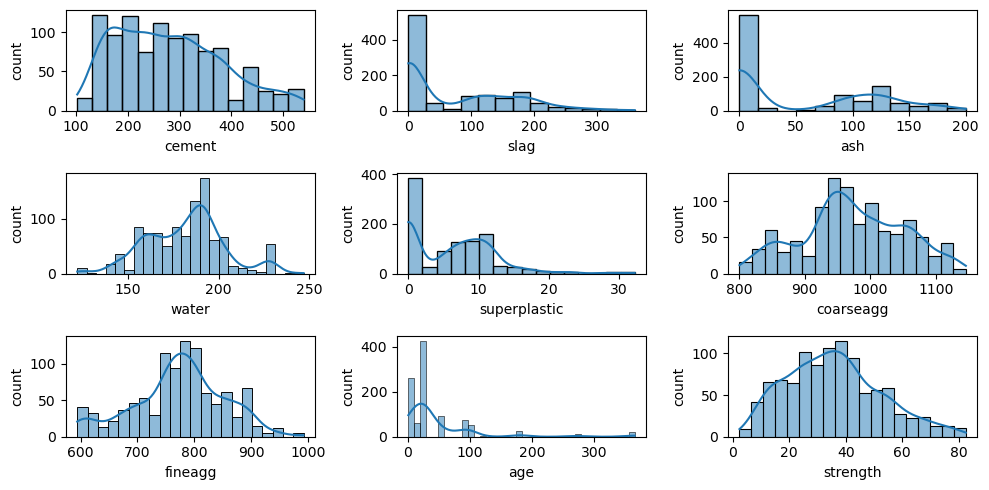

In [11]:
plt.figure(figsize=(10,5), facecolor='white')
plotnumber = 1

for column in data:
    if plotnumber <= 9:
        ax = plt.subplot(3,3, plotnumber)
        sns.histplot(x=data[column], kde=True)

        plt.xlabel(column, fontsize=10)
        plt.ylabel("count", fontsize=10)

    plotnumber += 1

plt.tight_layout()
plt.show()

#### Insights:-

- **Cement** → Slight right skew; fairly spread, not normally distributed.
- **Slag** → Highly right-skewed; many zero values.
- **Ash** → Strong right skew; mostly zero or small values.
- **Water** → Slight right skew; moderately uniform spread, near-normal.
- **Superplasticizer** → Strong right skew; most values near zero.
- **Coarse Aggregate** → Almost symmetrical, approximates normal distribution.
- **Fine Aggregate** → Nearly symmetric but slight left skew.
- **Age** → Extremely right-skewed; most samples low age, few very high.



### b) Bivariate Analysis

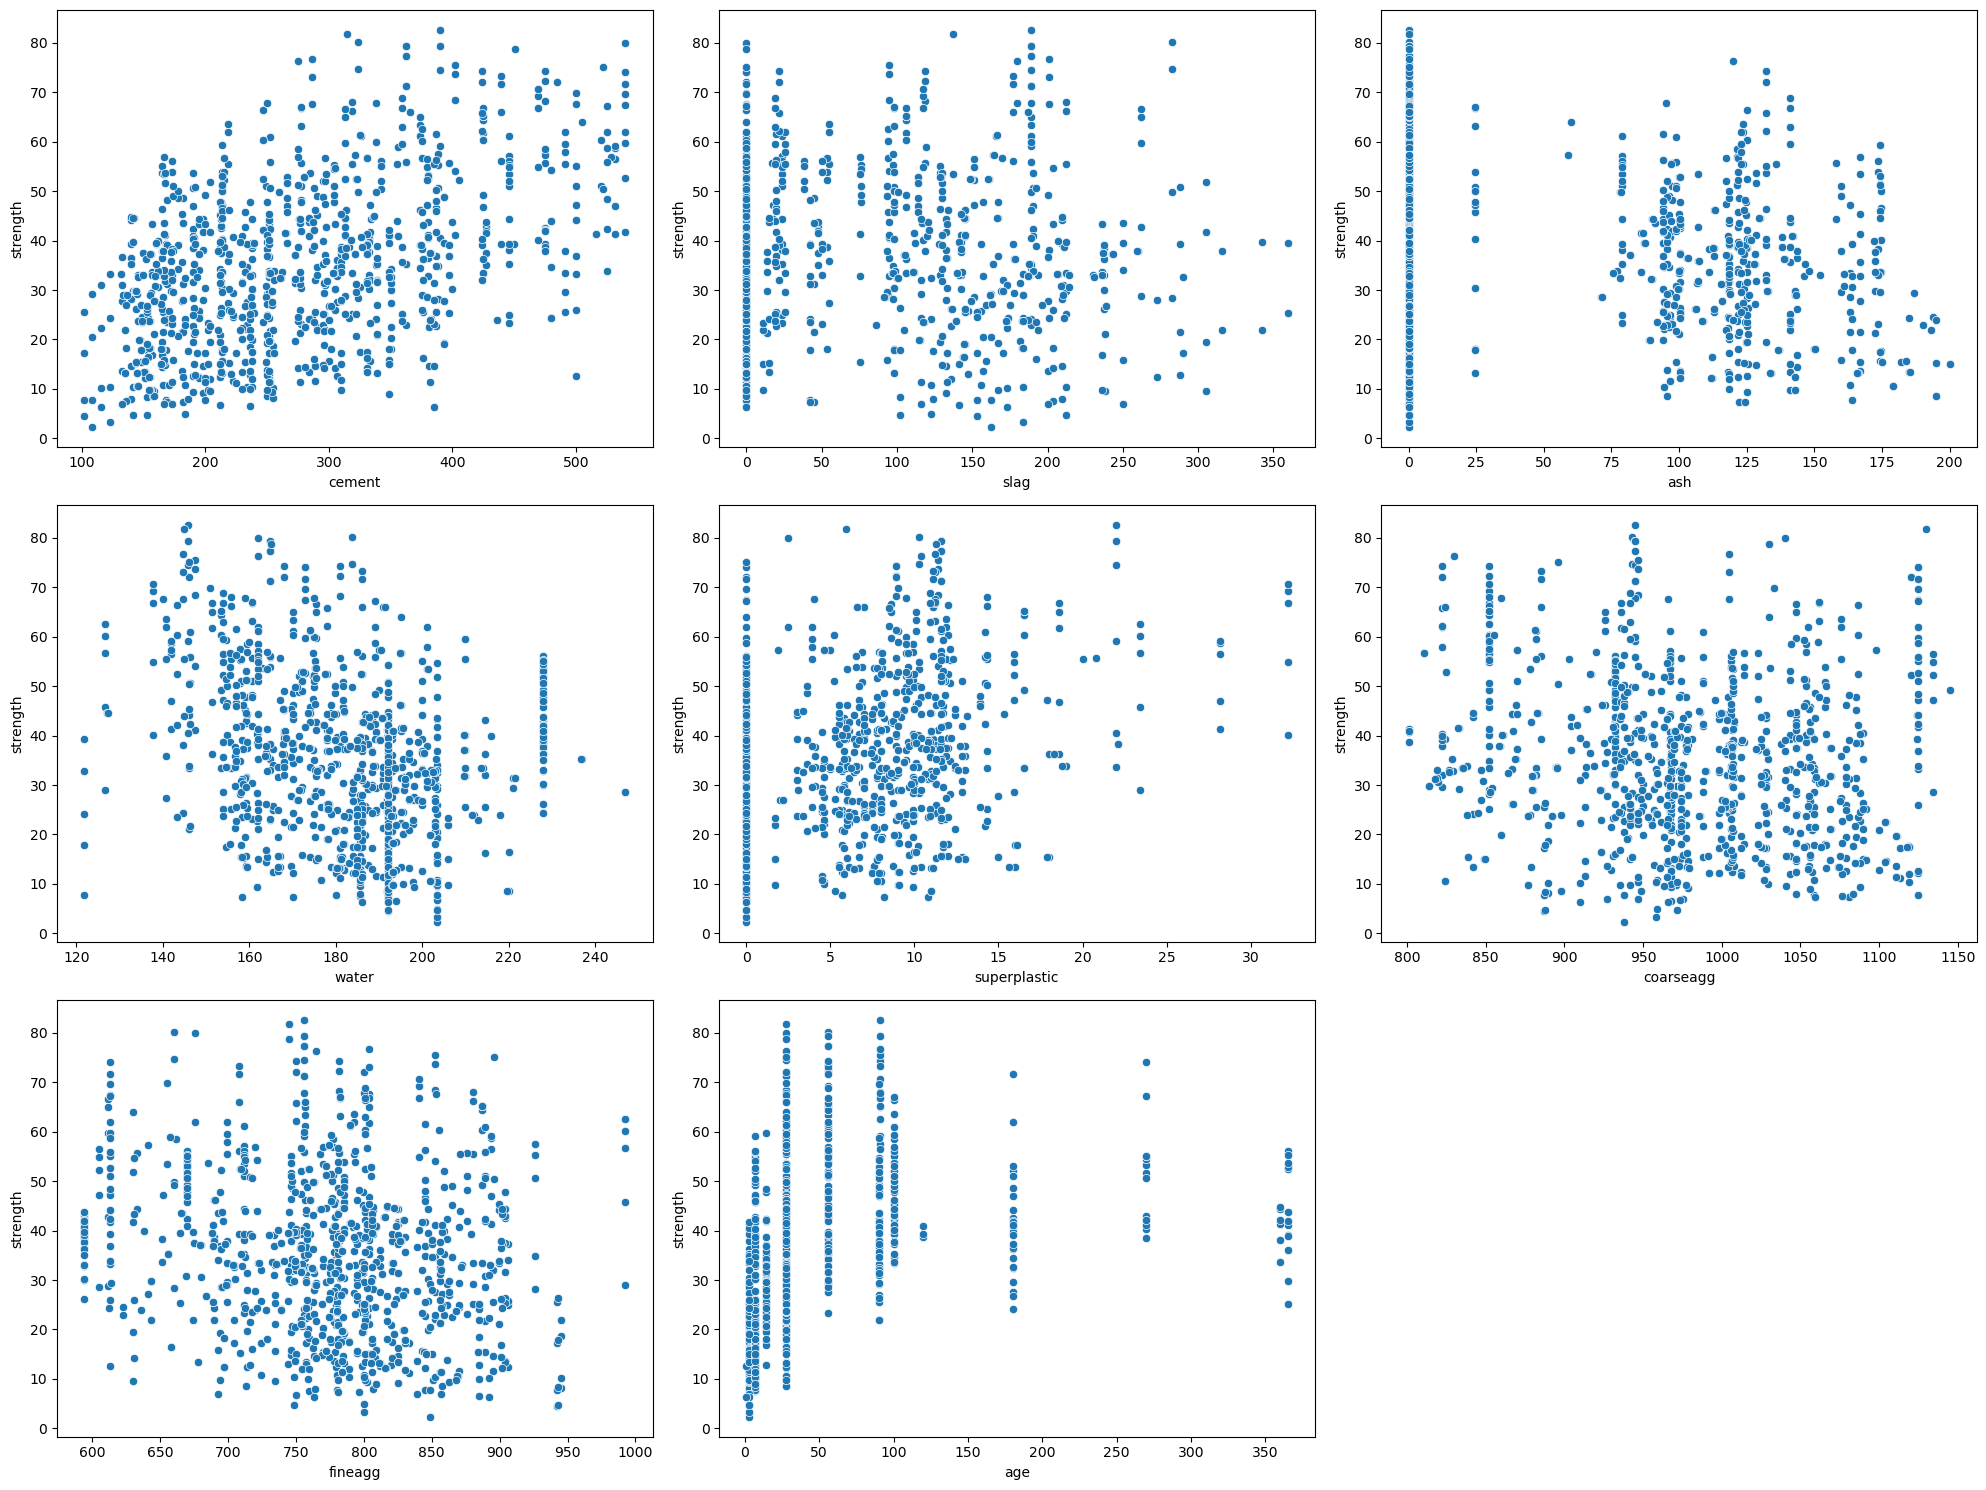

In [12]:
plt.figure(figsize=(20,15), facecolor='white')
plotnumber = 1

for column in data.drop('strength', axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3, plotnumber)
        sns.scatterplot(data=data, x=data[column], y='strength')

        plt.xlabel(column, fontsize=10)
        plt.ylabel("strength", fontsize=10)

    plotnumber += 1

plt.tight_layout()
plt.show()

#### Insights:-
- **Cement vs Strength** → **Strong positive correlation**
   More cement generally increases strength.

- **Slag vs Strength** → **Slight positive correlation**
   Higher slag content may improve strength in some mixes.

- **Ash vs Strength** → **Weak and scattered**
   No clear direct correlation.

- **Water vs Strength** → **Negative correlation**
   Higher water content leads to lower strength.

- **Superplasticizer vs Strength** → **Moderate positive correlation**
   Helps achieve strength by reducing water demand.

- **Coarse Aggregate vs Strength** → **Weak relationship**
   Points spread without a clear trend.

- **Fine Aggregate vs Strength** → **Very weak or no clear correlation**
   Strength not significantly influenced by fine aggregates alone.

- **Age vs Strength** → **Strong positive correlation**
   Strength increases as concrete cures over time.


### c) Multivariate Analysis

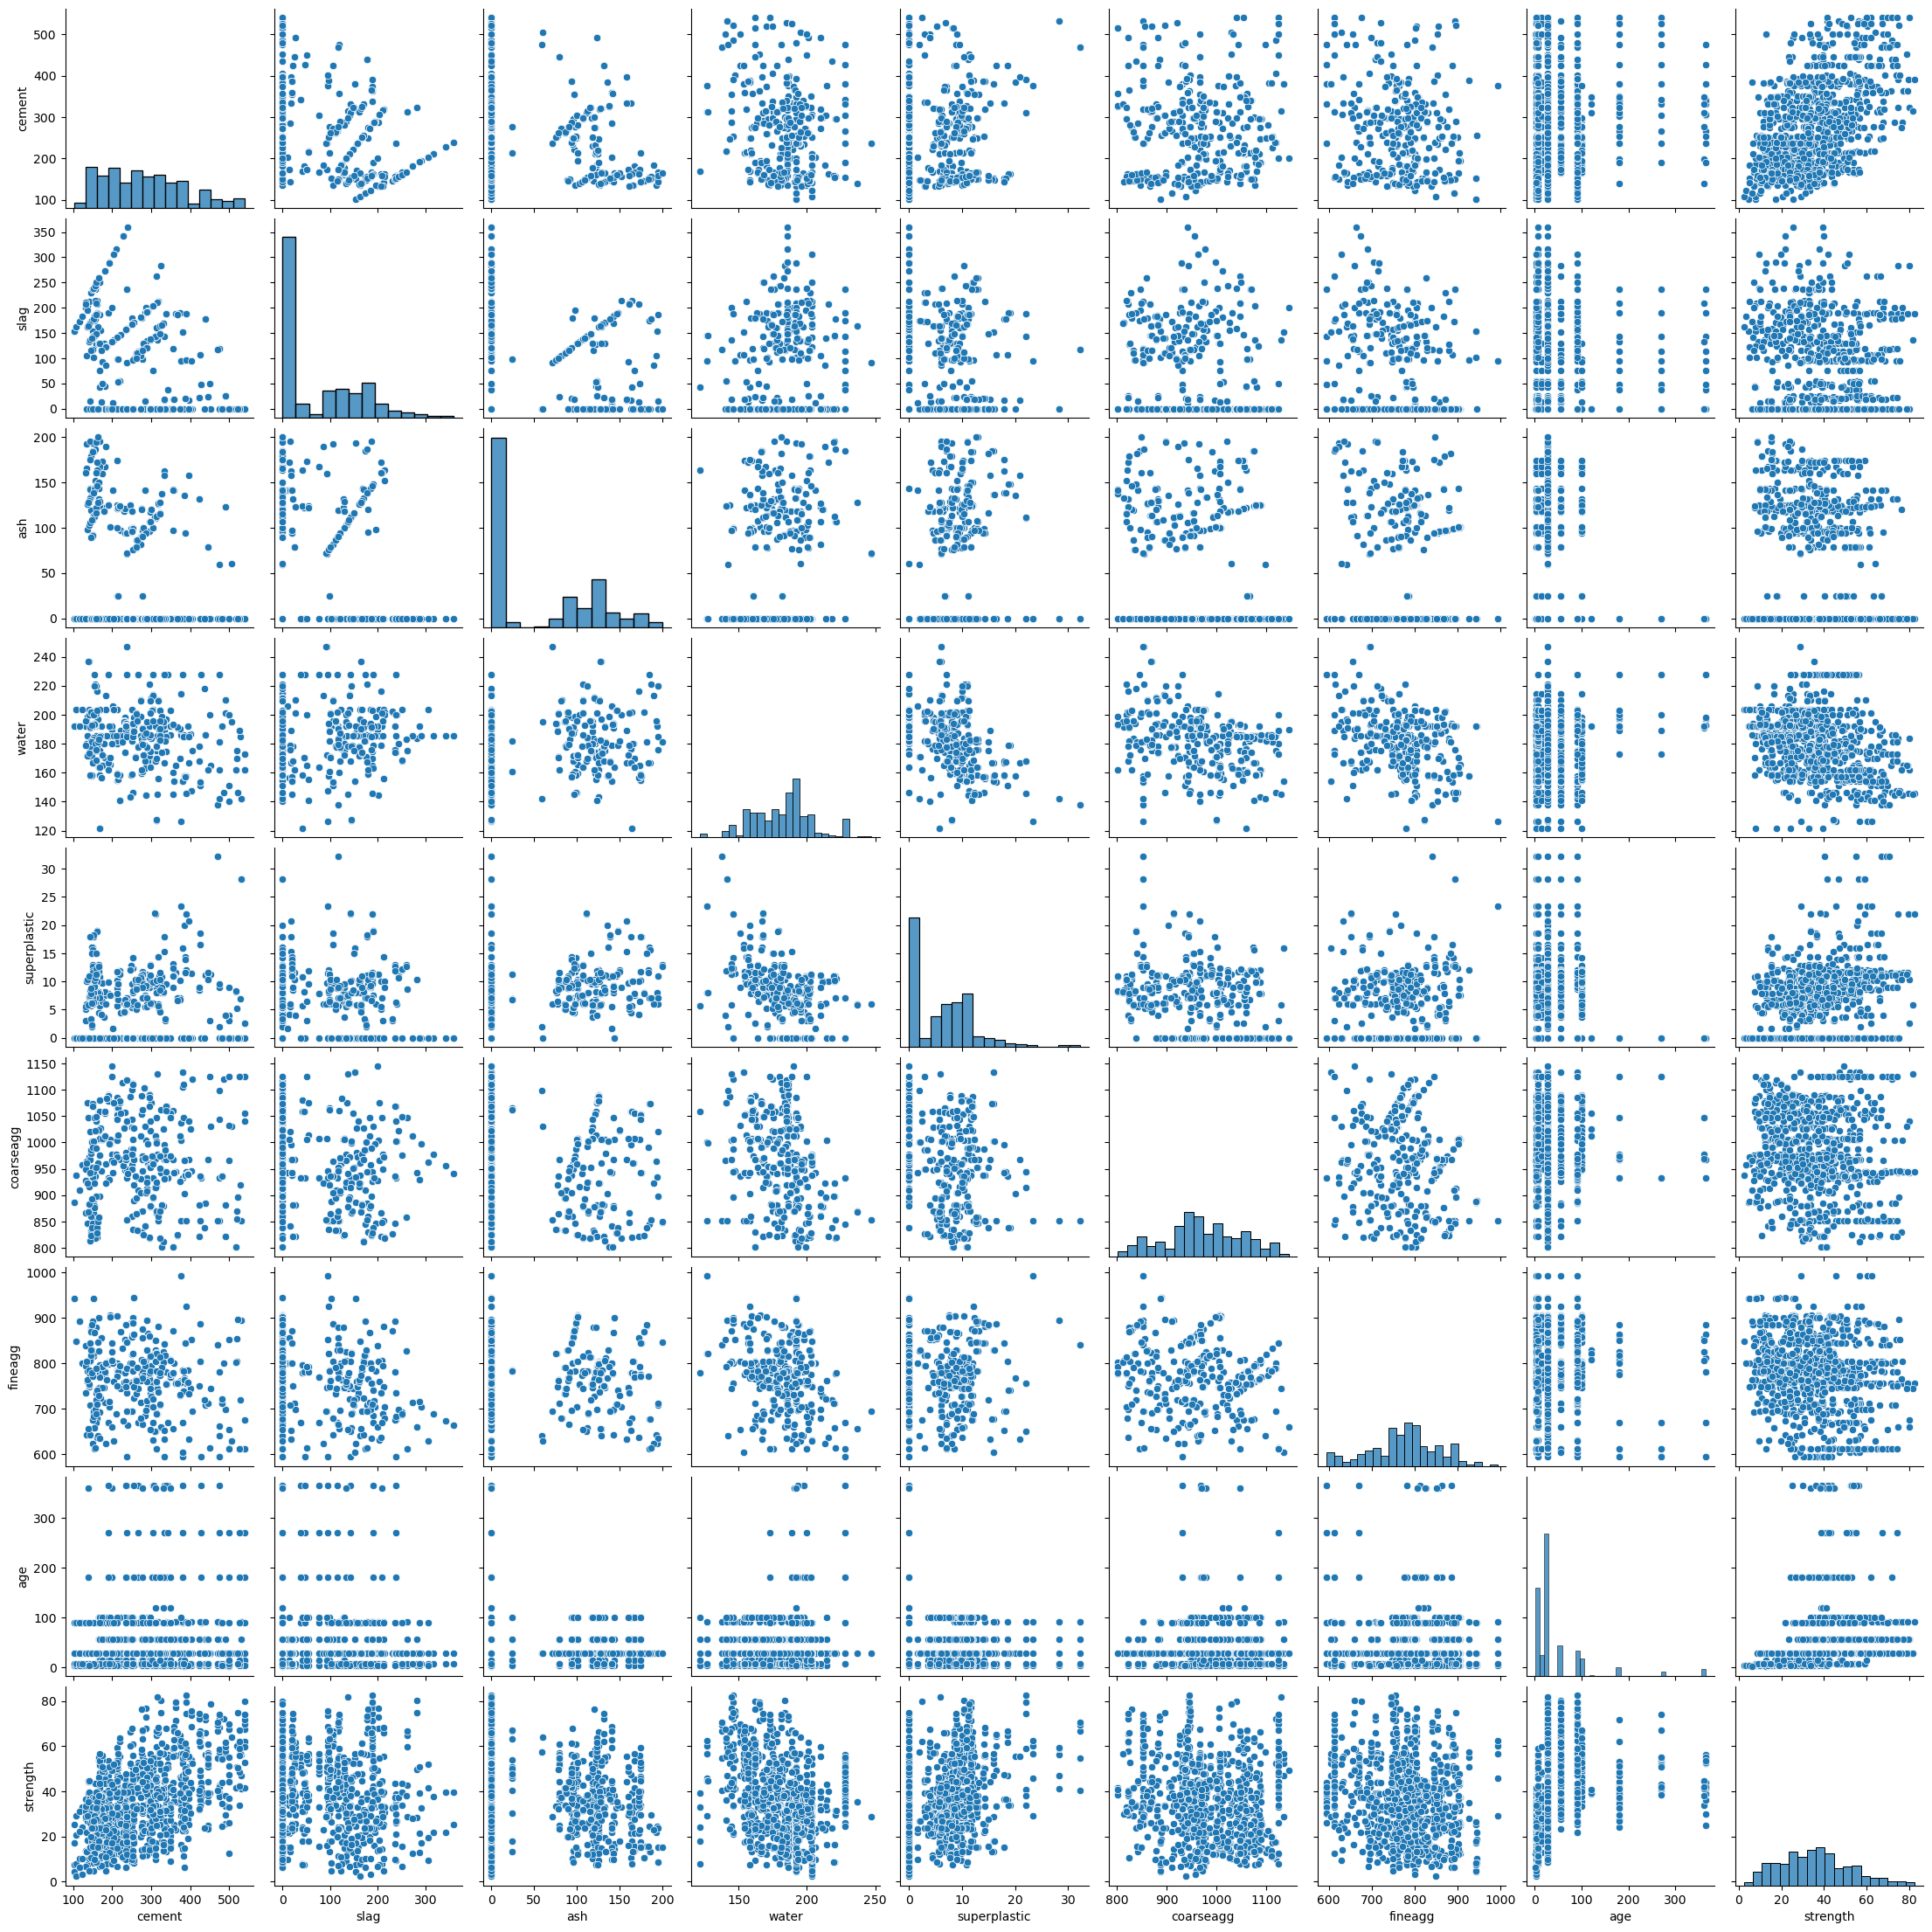

In [13]:
sns.pairplot(data)
plt.show()

# STEP 7: Data Preprocessing-
### a) Check for missing values and handle them:

In [14]:
data.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

### b) Check for Duplicate values:

In [15]:
data.duplicated().sum()

np.int64(25)

In [16]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

### c) Feature adding:

In [17]:
data["water_cement_ratio"] = data["water"] / data["cement"]
data["total_agg"] = data["coarseagg"] + data["fineagg"]
data["binder"] = data["cement"] + data["slag"] + data["ash"]
data["slag_ratio"] = data["slag"] / (data["binder"])
data["ash_ratio"] = data["ash"] / (data["binder"])
data["agg_binder_ratio"] = data["total_agg"] / data["binder"]

In [18]:
data.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,water_cement_ratio,total_agg,binder,slag_ratio,ash_ratio,agg_binder_ratio
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000,1716.0,540.0,0.0,0.0,3.177778
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000,1731.0,540.0,0.0,0.0,3.205556
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0.685714,1526.0,475.0,0.3,0.0,3.212632
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0.685714,1526.0,475.0,0.3,0.0,3.212632
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,0.966767,1803.9,331.0,0.4,0.0,5.449849


### d) Applying log transformation to highly skewed data:

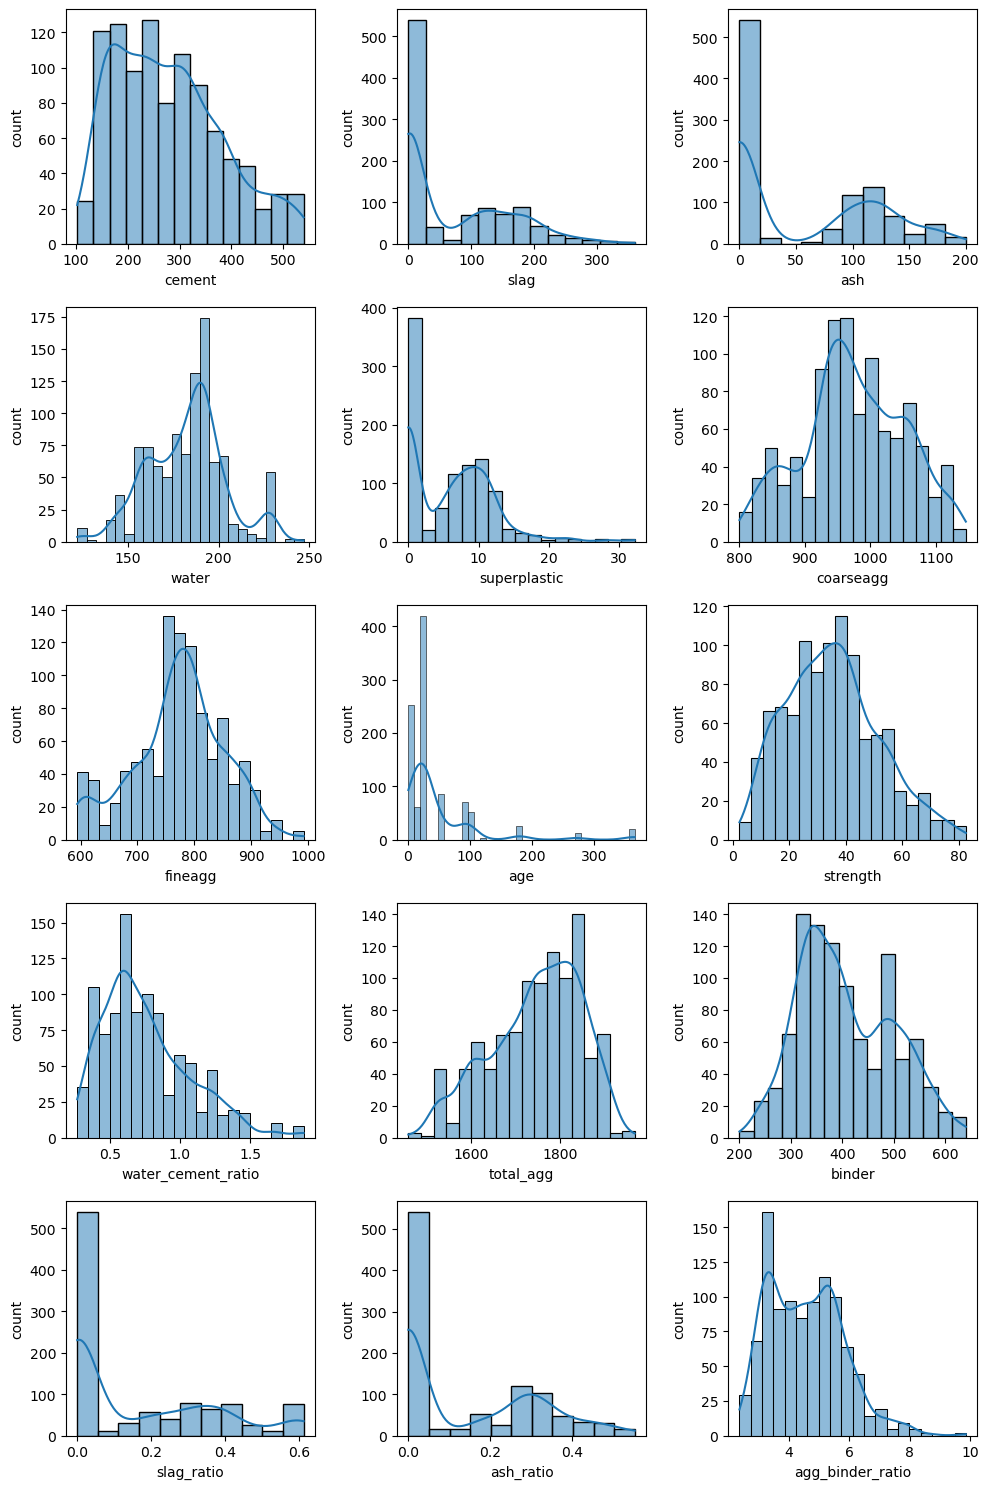

In [19]:
plt.figure(figsize=(10,15), facecolor='white')
plotnumber = 1

for column in data:
    if plotnumber <= 15:
        ax = plt.subplot(5,3, plotnumber)
        sns.histplot(x=data[column], kde=True)

        plt.xlabel(column, fontsize=10)
        plt.ylabel("count", fontsize=10)

    plotnumber += 1

plt.tight_layout()
plt.show()

- Slag – Extremely right-skewed with many zero values and a long high-value tail → log transform reduces extreme magnitude impact.

- Ash – Majority values near zero, heavy right skew → log transform normalizes distribution.

- Superplasticizer – Small values dominate with few large spikes → log transform stabilizes variance.

- Age – Long right tail due to few long-curing samples → log transform prevents rare high ages from biasing model.

- Water-Cement Ratio – Mild right skew and uneven spread → log transform improves linear relationship with strength.

- Slag Ratio – Highly imbalanced with most values close to zero → log transform reduces asymmetry.

- Ash Ratio – Strong right skew similar to slag ratio → log transform makes distribution more uniform.

In [20]:
new_data = data.copy()

In [21]:
skewed_features = ['slag', 'ash', 'superplastic', 'age', 'water_cement_ratio', 'slag_ratio', 'ash_ratio']

for col in skewed_features:
    new_data[col] = np.log1p(new_data[col])

In [22]:
new_data.isnull().sum()

cement                0
slag                  0
ash                   0
water                 0
superplastic          0
coarseagg             0
fineagg               0
age                   0
strength              0
water_cement_ratio    0
total_agg             0
binder                0
slag_ratio            0
ash_ratio             0
agg_binder_ratio      0
dtype: int64

In [23]:
new_data.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,water_cement_ratio,total_agg,binder,slag_ratio,ash_ratio,agg_binder_ratio
0,540.0,0.000000,0.0,162.0,1.252763,1040.0,676.0,3.367296,79.99,0.262364,1716.0,540.0,0.000000,0.0,3.177778
1,540.0,0.000000,0.0,162.0,1.252763,1055.0,676.0,3.367296,61.89,0.262364,1731.0,540.0,0.000000,0.0,3.205556
2,332.5,4.966335,0.0,228.0,0.000000,932.0,594.0,5.602119,40.27,0.522189,1526.0,475.0,0.262364,0.0,3.212632
3,332.5,4.966335,0.0,228.0,0.000000,932.0,594.0,5.902633,41.05,0.522189,1526.0,475.0,0.262364,0.0,3.212632
4,198.6,4.893352,0.0,192.0,0.000000,978.4,825.5,5.888878,44.30,0.676391,1803.9,331.0,0.336472,0.0,5.449849


### e) Check for Outliers:

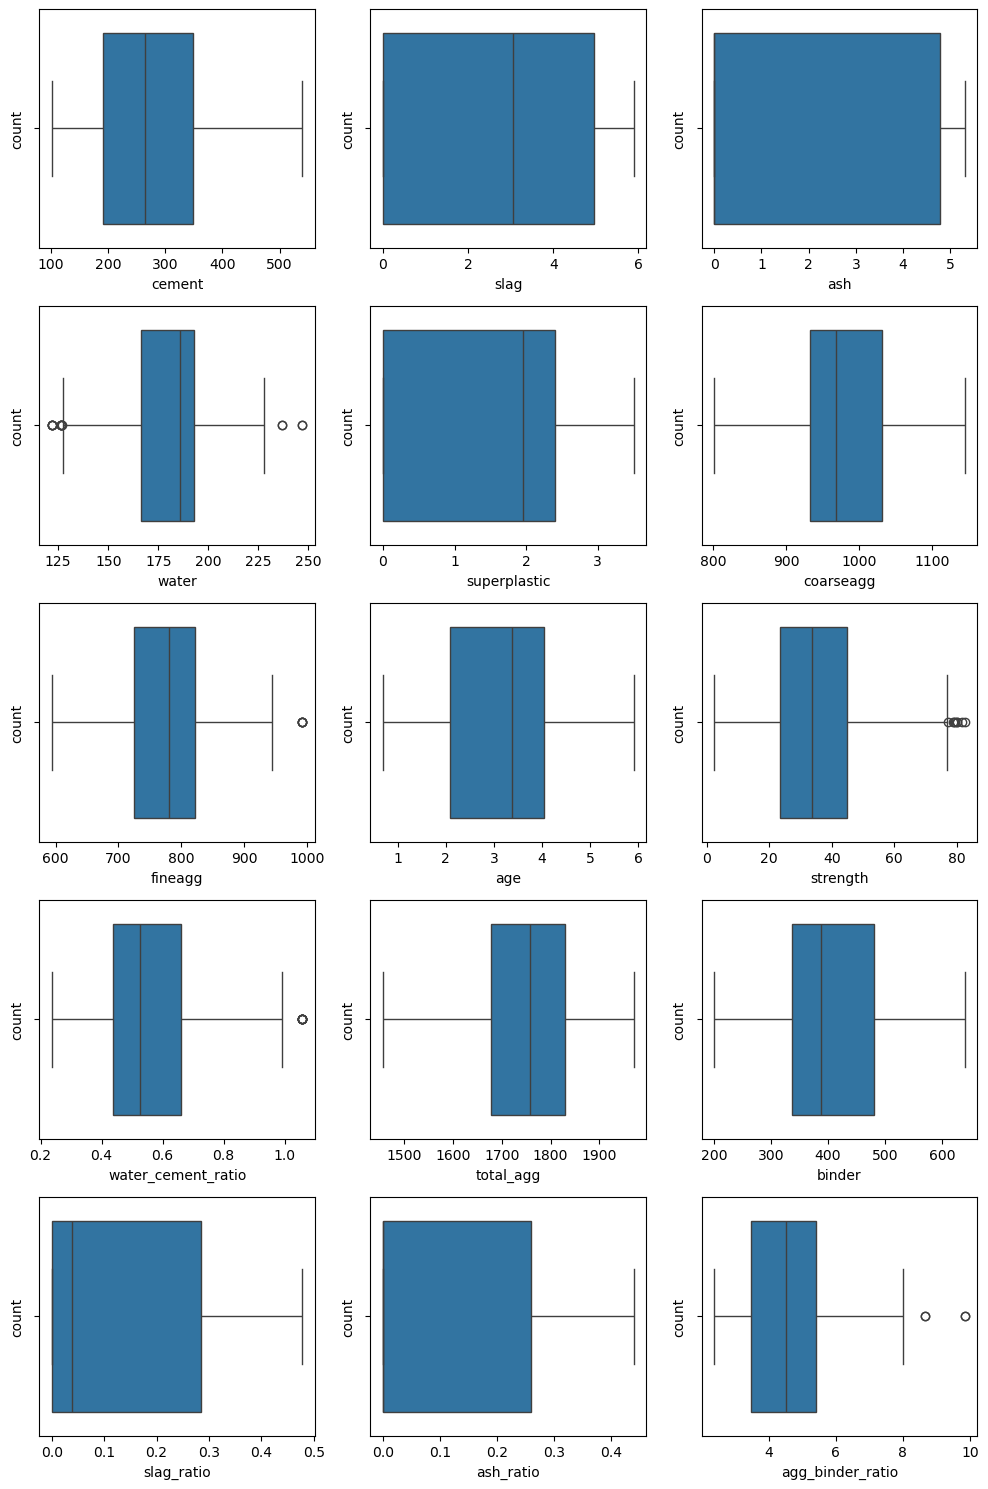

In [24]:
plt.figure(figsize=(10,15), facecolor='white')
plotnumber = 1

for column in new_data:
    if plotnumber <= 15:
        ax = plt.subplot(5,3, plotnumber)
        sns.boxplot(x=new_data[column])

        plt.xlabel(column, fontsize=10)
        plt.ylabel("count", fontsize=10)

    plotnumber += 1

plt.tight_layout()
plt.show()

#### Insights:-
* water and fineagg has few outliers.Fine Aggregate (fineagg) shows clear outliers on the higher end, indicating extreme values that can distort model learning.
Outlier treatment applied to improve model stability.

* Other features like water, strength, and agg_binder_ratio show some outliers, but:
   - They have strong correlation with target (strength)
   - Removing/altering them may remove valid concrete behavior
   - They are better handled naturally by tree-based models

#### Find Outliers in fineagg:-

In [25]:
Q1 = new_data['fineagg'].quantile(0.25) # 1/4th value
Q3 = new_data['fineagg'].quantile(0.75) # 3/4th value
IQR = Q3-Q1

lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR

print(f"Values above upper limit:\n{new_data.loc[new_data['fineagg'] > upper_limit]}\n")
print(f"Percentage: {(len(new_data.loc[new_data['fineagg'] > upper_limit])/len(new_data))*100}%\n")

print(f"Values below lower limit:\n{new_data.loc[new_data['fineagg'] < lower_limit]}\n")
print(f"Percentage: {(len(new_data.loc[new_data['fineagg'] < lower_limit])/len(new_data))*100}%\n")

Values above upper limit:
     cement      slag  ash  water  superplastic  coarseagg  fineagg       age  \
74    375.0  4.551769  0.0  126.6      3.194583      852.1    992.6  1.386294   
97    375.0  4.551769  0.0  126.6      3.194583      852.1    992.6  2.079442   
120   375.0  4.551769  0.0  126.6      3.194583      852.1    992.6  3.367296   
143   375.0  4.551769  0.0  126.6      3.194583      852.1    992.6  4.043051   
166   375.0  4.551769  0.0  126.6      3.194583      852.1    992.6  4.521789   

     strength  water_cement_ratio  total_agg  binder  slag_ratio  ash_ratio  \
74       29.0            0.290877     1844.7   468.8    0.182393        0.0   
97       45.7            0.290877     1844.7   468.8    0.182393        0.0   
120      56.7            0.290877     1844.7   468.8    0.182393        0.0   
143      60.2            0.290877     1844.7   468.8    0.182393        0.0   
166      62.5            0.290877     1844.7   468.8    0.182393        0.0   

     agg_bin

0.4% is less than 5%, so we can handle the outliers.

In [26]:
new_data.loc[new_data['fineagg'] > upper_limit, "fineagg"] = new_data['fineagg'].median()

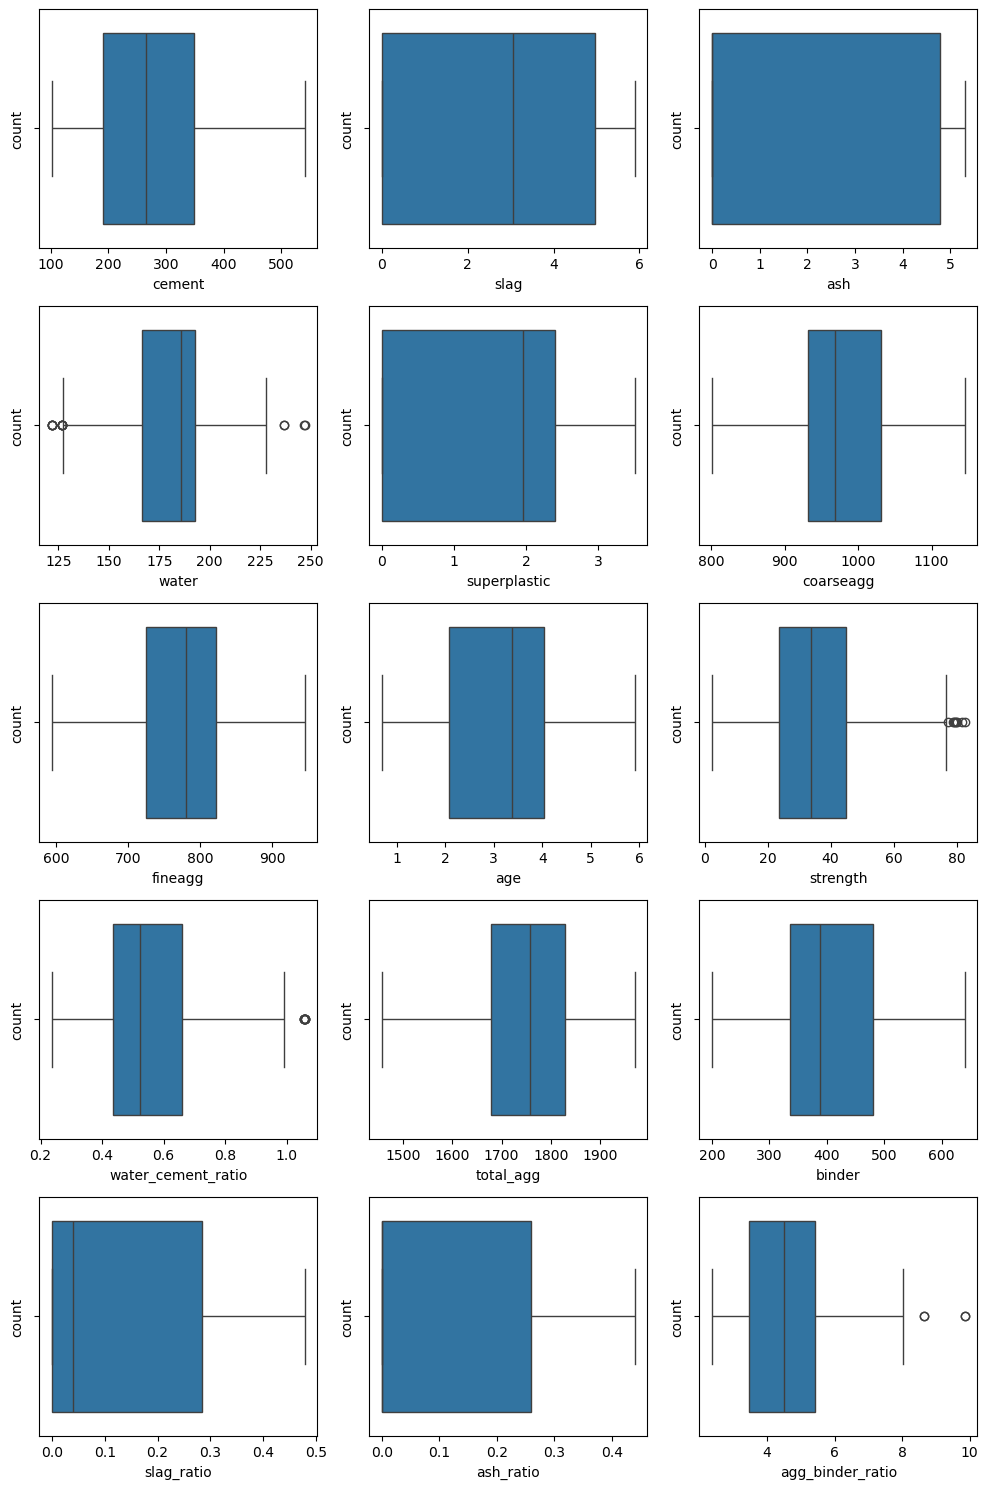

In [27]:
plt.figure(figsize=(10,15), facecolor='white')
plotnumber = 1

for column in new_data:
    if plotnumber <= 15:
        ax = plt.subplot(5,3, plotnumber)
        sns.boxplot(x=new_data[column])

        plt.xlabel(column, fontsize=10)
        plt.ylabel("count", fontsize=10)

    plotnumber += 1

plt.tight_layout()
plt.show()

# STEP 8: Feature Engineering-

### a) Drop the columns which has very less correlation with target variables:

In [28]:
new_data.corr()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,water_cement_ratio,total_agg,binder,slag_ratio,ash_ratio,agg_binder_ratio
cement,1.000000,-0.236552,-0.347817,-0.056625,-0.062404,-0.086205,-0.262508,0.006433,0.488283,-0.909619,-0.258249,0.584629,-0.397661,-0.436925,-0.493206
slag,-0.236552,1.000000,-0.193303,0.057476,0.111610,-0.345111,-0.277336,-0.007035,0.183372,0.298138,-0.466889,0.438181,0.909634,-0.267922,-0.464093
ash,-0.347817,-0.193303,1.000000,-0.290820,0.628112,-0.029539,0.140605,-0.026988,-0.046562,0.201349,0.076456,-0.028853,-0.328818,0.951376,-0.012354
water,-0.056625,0.057476,-0.290820,1.000000,-0.603978,-0.212480,-0.418566,0.171911,-0.269624,0.325915,-0.510883,-0.140828,0.164860,-0.297597,0.006618
superplastic,-0.062404,0.111610,0.628112,-0.603978,1.000000,-0.215816,0.168283,-0.045494,0.316193,-0.111954,-0.018147,0.336140,-0.062739,0.576213,-0.309791
coarseagg,-0.086205,-0.345111,-0.029539,-0.212480,-0.215816,1.000000,-0.144140,-0.042163,-0.144717,-0.032241,0.631400,-0.378600,-0.252174,0.049457,0.428164
fineagg,-0.262508,-0.277336,0.140605,-0.418566,0.168283,-0.144140,1.000000,-0.116033,-0.202883,0.103626,0.662726,-0.508347,-0.220444,0.172600,0.581559
age,0.006433,-0.007035,-0.026988,0.171911,-0.045494,-0.042163,-0.116033,1.000000,0.559853,0.026034,-0.123003,-0.026480,-0.013337,-0.014838,-0.024483
strength,0.488283,0.183372,-0.046562,-0.269624,0.316193,-0.144717,-0.202883,0.559853,1.000000,-0.510686,-0.256342,0.598103,0.023300,-0.130466,-0.554550
water_cement_ratio,-0.909619,0.298138,0.201349,0.325915,-0.111954,-0.032241,0.103626,0.026034,-0.510686,1.000000,0.039758,-0.507354,0.495912,0.287731,0.398708


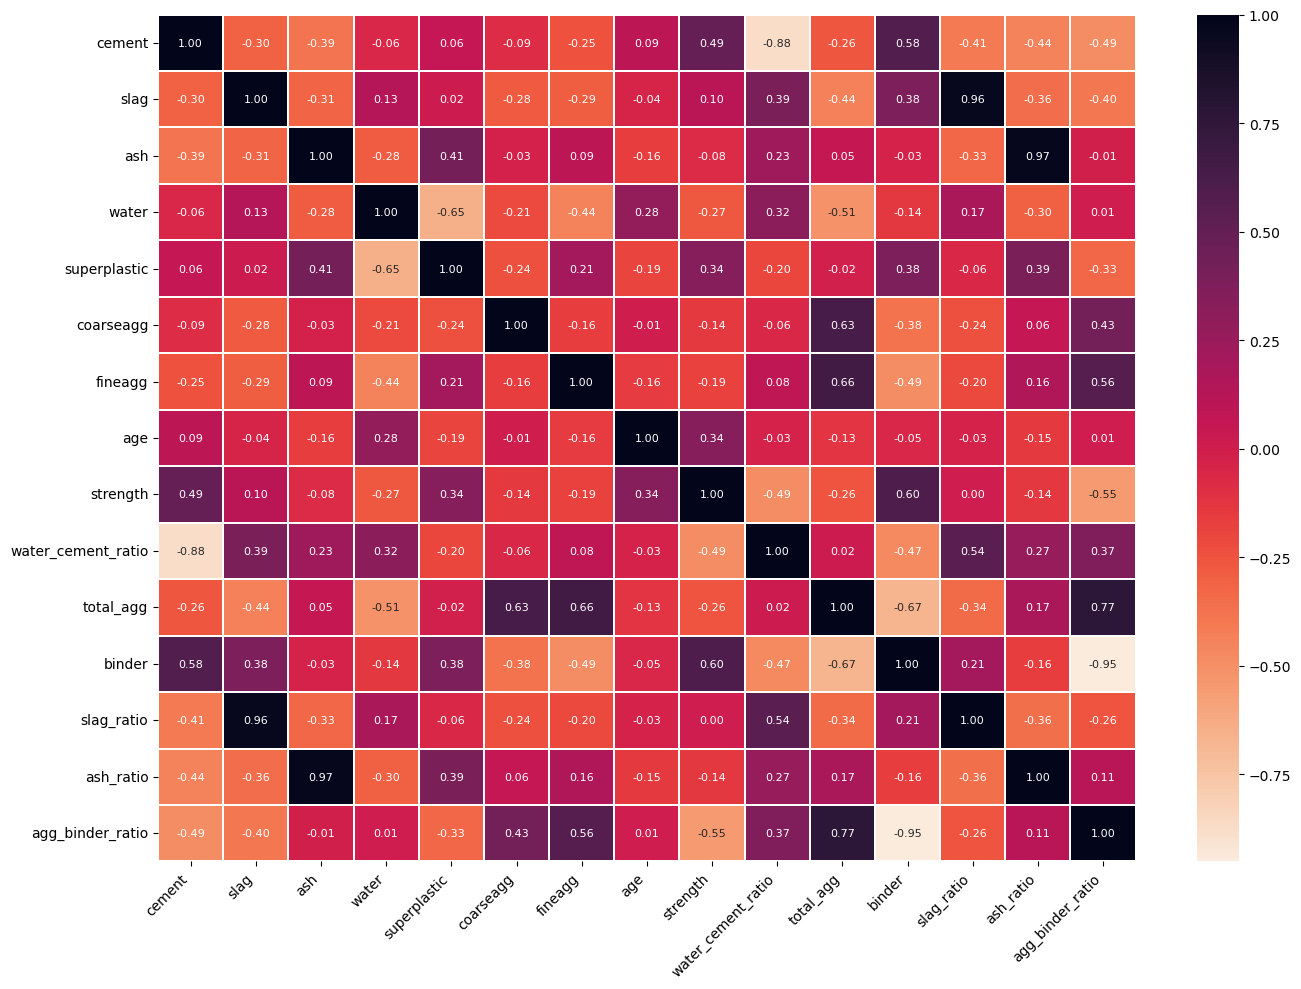

In [29]:
plt.figure(figsize=(14,10))  # Bigger figure

corr = data.corr()

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="rocket_r",   # your style
            annot_kws={"size": 8},  # smaller text
            linewidths=0.3,
            cbar=True)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Insights:-

1. **Higher binder and cement content strongly increase compressive strength**, making them the most influential predictors.
2. **Water-cement ratio has a strong negative correlation**, meaning excess water reduces strength by increasing porosity.
3. **Age positively affects strength**, confirming concrete gains strength as curing progresses.
4. **Aggregate-to-binder ratio negatively impacts strength**; too much aggregate weakens the bond and lowers strength.
5. **Superplasticizer shows a positive correlation**, improving strength by enhancing compaction and reducing voids.
6. **Slag and ash ratios are highly correlated with their base quantities**, indicating redundancy and potential multicollinearity in linear models.


Since we have a small dataset, we are not dropping any features

### b) Drop one of the column if two input variables has high correlation:

Check for multicolliniarility - there should not be any high correlation among input variables.

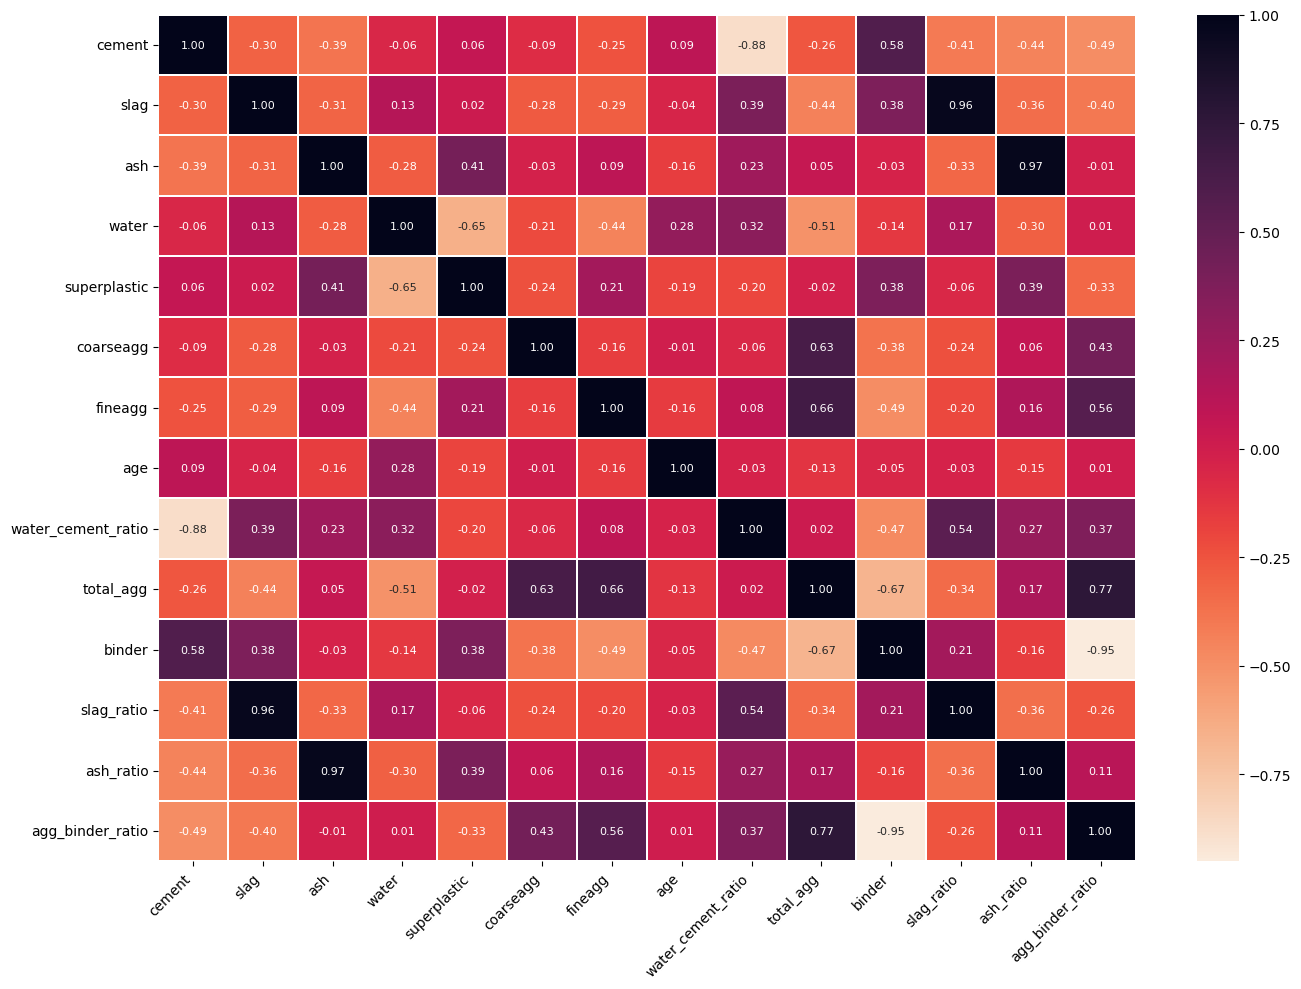

In [30]:
plt.figure(figsize=(14,10))  # Bigger figure

corr = data.drop('strength', axis=1).corr()

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="rocket_r",   # your style
            annot_kws={"size": 8},  # smaller text
            linewidths=0.3,
            cbar=True)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Since the dataset is small we are not removing any features.


---

# 📄 **Concrete Strength – Data Analysis Report**

## **1. Dataset Loading & Basic Checks**

* Loaded dataset using `pd.read_csv()`.
* Displayed **head, tail, shape, columns, dtypes, info, describe()**.
* Dataset contains **1030 rows × 9 columns**.
* All columns are **numeric**.
* **No missing values** were found.

---

## **2. Duplicate Analysis**

* Found **25 duplicate rows**.
* Removed them using `drop_duplicates()`.
* Final dataset now contains **1005 rows**.

---

## **3. Univariate Analysis (Histograms)**

* Cement: mild right skew; wide distribution.
* Slag & Ash: highly right-skewed; many zeros.
* Water: nearly uniform; slight skew.
* Superplasticizer: heavily right-skewed.
* Coarse & Fine Aggregates: close to symmetric.
* Age: extremely right-skewed (1 to 365 days).
* Strength: slightly right-skewed.

---

## **4. Bivariate Analysis (Feature vs Strength)**

* **Cement** → strong positive relationship.
* **Age** → strong positive relationship (strength increases with curing).
* **Water** → negative correlation (more water = lower strength).
* **Superplasticizer** → moderate positive effect.
* **Slag/Ash** → weak and scattered patterns.
* **Aggregates** → weak or no clear trends.

---

## **5. Multivariate Analysis**

* Pairplot shows no severe multicollinearity.
* Some negative correlations exist between aggregates and strength but not strong enough to drop features.

---

## **6. Feature Engineering**

Added domain-relevant features:

* **Water–Cement Ratio**
* **Total Aggregates**
* **Binder (cement + slag + ash)**
* **Slag Ratio**
* **Ash Ratio**
* **Aggregate–Binder Ratio**

These better capture concrete mix proportions and improve model learning.

---

## **7. Skewness Handling**

Applied **log1p transformation** to highly skewed features:

* slag
* ash
* superplastic
* age
* water_cement_ratio
* slag_ratio
* ash_ratio

This reduced extreme right skew and stabilized distributions.

---

## **8. Outlier Analysis & Handling**

* Boxplots revealed outliers in **slag, ash, superplastic, age, and ratios**.
* These features also have important relationships with the target → **kept as is**.
* Applied **IQR capping only on fineagg**, as its outliers do not contribute strongly to strength.

---

## **9. Final Clean Dataset Ready for Modeling**

* No duplicates
* No missing values
* Skewness reduced
* Outliers treated appropriately
* Useful engineered features added
* Dataset prepared for train-test split and scaling (where needed)

---

## **10. Feature Selection & Importance (Heatmap Insights)**

* A correlation heatmap was generated to study relationships between features and the target variable.
* Cement, Age, Water, and Superplasticizer showed the strongest correlations with strength.
* Other features (slag, ash, aggregates) showed weaker relationships but still contribute useful information.
* Since the dataset is small, and no feature showed harmful multicollinearity or redundancy, no columns were dropped.
* All original features were retained, along with engineered features, for modeling.

---


### ✔ **Summary**

The dataset was cleaned, explored, transformed, and enriched through feature engineering.
Key predictors of strength include **cement, age, water, and superplasticizer**, with additional engineered ratios improving representation of the concrete mix. The final processed dataset is now ready for applying regression and tree models.

---



# STEP 9: Split Data into x and y-

In [31]:
x = new_data.drop("strength", axis=1)
y = new_data.strength

# STEP 10: Split Data for training and testing-

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [33]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)  # fit + transform on train
x_test_scaled = scaler.transform(x_test)        # only transform test

In [34]:
x_train_scaled.shape

(804, 14)

In [35]:
x_test_scaled.shape

(201, 14)

# STEP 11: Model Building-

## 1) Linear Regression:-

In [36]:
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


###

In [37]:
# make predictions/test model
y_pred1 = lr.predict(x_test_scaled)

In [38]:
# Loss Functions to know the difference between actual and predicted values
# Different Error/Loss Functions in Regression algorithm are:
#  - MSE (Mean Squared Error)
#  - MAE (Mean Absolute Error)
#  - RMSE (Root Mean Squared Error)

In [39]:
mse_lr = mean_squared_error(y_test, y_pred1)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred1)
r2_lr = r2_score(y_test, y_pred1)

n = x_test_scaled.shape[0]
p = x_test_scaled.shape[1]

adj_r2_lr = 1 - (1 - r2_lr) * (n - 1) / (n - p - 1)

print("R2 (Linear Regression):", r2_lr)
print("Adjusted R2 (Linear Regression):", adj_r2_lr)
print("MSE (Linear Regression):", mse_lr)
print("RMSE (Linear Regression):", rmse_lr)
print("MAE (Linear Regression):", mae_lr)

R2 (Linear Regression): 0.827206786539438
Adjusted R2 (Linear Regression): 0.8142008457413312
MSE (Linear Regression): 51.548516334684834
RMSE (Linear Regression): 7.179729544675401
MAE (Linear Regression): 5.466327455880094


Since adjusted R2 score is less than R2 score:
* 82% better model to make prediction.
* Model has learnt 82% of the information.

In [40]:
cv_scores = cross_val_score(lr, x_train_scaled, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

0.8211538161958826 0.01417980108576284


## 2) Support Vector Machine (SVM):-

In [41]:
svr = SVR()
svr.fit(x_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [42]:
y_pred2 = svr.predict(x_test_scaled)

In [43]:
mse_svr = mean_squared_error(y_test, y_pred2)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_pred2)
r2_svr = r2_score(y_test, y_pred2)

n = x_test_scaled.shape[0]
p = x_test_scaled.shape[1]

adj_r2_svr = 1 - (1 - r2_svr) * (n - 1) / (n - p - 1)

print("R2 (SVR):", r2_svr)
print("Adjusted R2 (SVR):", adj_r2_svr)
print("MSE (SVR):", mse_svr)
print("RMSE (SVR):", rmse_svr)
print("MAE (SVR):", mae_svr)

R2 (SVR): 0.7642670780798013
Adjusted R2 (SVR): 0.746523739870754
MSE (SVR): 70.32499791434127
RMSE (SVR): 8.386000114139115
MAE (SVR): 5.914256739394077


In [44]:
cv_scores = cross_val_score(svr, x_train_scaled, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

0.764139893575255 0.028684272170047622


#### Hyper parameter Tuning:

In [45]:
# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

grid = GridSearchCV(SVR(), param_grid, verbose=1, scoring='r2', cv=3)

# fitting the model for grid search
grid.fit(x_train_scaled, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


#### Hyperparameter Tuning Strategy – SVR

- **Log-scale range for C (0.1 to 1000):**
The values for C were chosen on a logarithmic scale (0.1, 1, 10, 100, 1000) to cover a wide spectrum from strong regularization (low C, simpler model, more bias) to weak regularization (high C, more complex model, less bias but higher overfitting risk). This allows the grid search to explore both underfitting and overfitting regimes.

- **Log-scale range for gamma (1 to 0.0001):**
The gamma values were also selected on a logarithmic scale (1, 0.1, 0.01, 0.001, 0.0001). Higher gamma values make the model very sensitive to individual data points (more complex, risk of overfitting), while smaller values produce smoother functions (more generalized, risk of underfitting). This range lets the model find an appropriate balance between local flexibility and global smoothness.

- **GridSearchCV with R² scoring and cross-validation:**
GridSearchCV with cv=3 and scoring='r2' was used to evaluate each (C, gamma) combination based on cross-validated R². This ensures that the chosen hyperparameters are not just good on one split but are stable across multiple folds of the training data.

In [46]:
# print best parameter after tuning
print(grid.best_params_)

# print how the model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'C': 100, 'gamma': 0.1}
SVR(C=100, gamma=0.1)


In [47]:
svr_cv = SVR(C=100, gamma=0.1)
svr_cv.fit(x_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [48]:
y_pred2_cv = svr_cv.predict(x_test_scaled)

In [49]:
mse_svr_cv = mean_squared_error(y_test, y_pred2_cv)
rmse_svr_cv = np.sqrt(mse_svr_cv)
mae_svr_cv = mean_absolute_error(y_test, y_pred2_cv)
r2_svr_cv = r2_score(y_test, y_pred2_cv)

n = x_test_scaled.shape[0]
p = x_test_scaled.shape[1]

adj_r2_svr_cv = 1 - (1 - r2_svr_cv) * (n - 1) / (n - p - 1)

print("R2 (SVR Tuned):", r2_svr_cv)
print("Adjusted R2 (SVR Tuned):", adj_r2_svr_cv)
print("MSE (SVR Tuned):", mse_svr_cv)
print("RMSE (SVR Tuned):", rmse_svr_cv)
print("MAE (SVR Tuned):", mae_svr_cv)

R2 (SVR Tuned): 0.9091875201744613
Adjusted R2 (SVR Tuned): 0.9023521722306035
MSE (SVR Tuned): 27.09162302111166
RMSE (SVR Tuned): 5.2049613851700816
MAE (SVR Tuned): 2.984215793031117


In [50]:
cv_scores = cross_val_score(svr_cv, x_train_scaled, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

0.9053557494417739 0.01993665222850169


## 3) Random Forest:-

In [51]:
x = data.drop("strength", axis=1)
y = data.strength

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [53]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred3 = rf.predict(x_test)

In [55]:
mse_rf = mean_squared_error(y_test, y_pred3)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred3)
r2_rf = r2_score(y_test, y_pred3)

n = x_test.shape[0]      # number of test samples
p = x_test.shape[1]      # number of features

adj_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)

print("R2 (RF):", r2_rf)
print("Adjusted R2 (RF):", adj_r2_rf)
print("MSE (RF):", mse_rf)
print("RMSE (RF):", rmse_rf)
print("MAE (RF):", mae_rf)

R2 (RF): 0.9174503895256092
Adjusted R2 (RF): 0.911236977984526
MSE (RF): 24.626603433891393
RMSE (RF): 4.962519867354829
MAE (RF): 3.510925506988868


In [56]:
cv_scores = cross_val_score(rf, x_train, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

0.9033589691864385 0.015114832493208146


In [57]:
param_grid = {
    "n_estimators": [200, 300, 400],      # number of trees
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R2: 0.8776233807637679


#### Hyperparameter Tuning Strategy – Random Forest
- **n_estimators = [200, 300, 400]:**
  More trees typically improve performance by reducing variance.
  Range selected to balance accuracy and computational cost.
  (Too many trees → slower training with minimal gains.)

- **max_depth = [None, 5, 10, 15, 20]:**
  Controls complexity of each tree.
  None allows fully grown trees → high variance
  Lower depths reduce overfitting on small dataset
  Range tested to find the right balance of bias vs variance.

- **min_samples_split = [2, 5, 10]:**
  Ensures minimum observations required to split a node.
  Higher values → simplified trees, better generalization.

- **min_samples_leaf = [1, 2, 4]:**
  Minimum samples per leaf node.
  Larger values help avoid extremely deep branches and noisy splits.

- **max_features = ["auto", "sqrt"]:**
  Controls number of features considered per split.
  "sqrt" → common best practice for regression forests
  "auto" tests model behavior without restriction

In [58]:
rf_cv = RandomForestRegressor(max_depth = 20, max_features = 'sqrt', min_samples_leaf = 1, min_samples_split = 2, n_estimators = 300)
rf_cv.fit(x_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
y_pred3_cv = rf_cv.predict(x_test)

In [60]:
mse_rf_cv = mean_squared_error(y_test, y_pred3_cv)
rmse_rf_cv = np.sqrt(mse_rf_cv)
mae_rf_cv = mean_absolute_error(y_test, y_pred3_cv)
r2_rf_cv = r2_score(y_test, y_pred3_cv)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_rf_cv = 1 - (1 - r2_rf_cv) * (n - 1) / (n - p - 1)

print("R2 (RF Tuned):", r2_rf_cv)
print("Adjusted R2 (RF Tuned):", adj_r2_rf_cv)
print("MSE (RF Tuned):", mse_rf_cv)
print("RMSE (RF Tuned):", rmse_rf_cv)
print("MAE (RF Tuned):", mae_rf_cv)

R2 (RF Tuned): 0.8905086298634581
Adjusted R2 (RF Tuned): 0.8822673439392023
MSE (RF Tuned): 32.664000911579514
RMSE (RF Tuned): 5.715242856745417
MAE (RF Tuned): 4.139774592250389


In [61]:
cv_scores = cross_val_score(rf_cv, x_train, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

0.877069732780341 0.0213164070625559


## 4) GradientBoost Regressor:

In [62]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(x_train, y_train)
y_pred4 = gb.predict(x_test)

In [63]:
mse_gb = mean_squared_error(y_test, y_pred4)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test, y_pred4)
r2_gb = r2_score(y_test, y_pred4)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_gb = 1 - (1 - r2_gb) * (n - 1) / (n - p - 1)

print("R2 (GradientBoost Regressor):", r2_gb)
print("Adjusted R2 (GradientBoost Regressor):", adj_r2_gb)
print("MSE (GradientBoost Regressor):", mse_gb)
print("RMSE (GradientBoost Regressor):", rmse_gb)
print("MAE (GradientBoost Regressor):", mae_gb)

R2 (GradientBoost Regressor): 0.9105653670925261
Adjusted R2 (GradientBoost Regressor): 0.9038337280564797
MSE (GradientBoost Regressor): 26.680576991350925
RMSE (GradientBoost Regressor): 5.165324480741837
MAE (GradientBoost Regressor): 3.8590549101426577


In [64]:
cv_scores = cross_val_score(gb, x_train, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

0.9029824050348114 0.014619579301983536


In [65]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(x_train, y_train)

print("Best params:", gb_grid.best_params_)
print("Best CV R2:", gb_grid.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.8}
Best CV R2: 0.9291514228239238


#### Hyperparameter Tuning Strategy – GradientBoost
- **n_estimators: [100, 200, 300]:**
  Increasing the number of trees generally improves model learning but also raises computation cost and risk of overfitting.
  This range allows finding the best balance.

- **learning_rate: [0.05, 0.1, 0.2]:**
  Controls how much each tree contributes to the final model.
  The selected range tests lower → moderate → higher learning speeds to balance bias vs variance.

- **max_depth: [2, 3, 4]:**
  Shallow trees reduce overfitting while capturing essential non-linear interactions.
  Depth beyond 4 adds complexity without substantial gain for this dataset.

- **subsample: [0.8, 1.0]:**
  Using less than 100% of data per tree introduces randomness → improves generalization and avoids overfitting.

- **min_samples_split: [2, 5]:**
  Prevents very small splits; testing values ensures decision splits form only when statistically meaningful.

- **min_samples_leaf: [1, 2]:**
  Controls minimum leaf size to reduce noise and stabilize predictions on small datasets.

In [66]:
gb_cv = GradientBoostingRegressor(learning_rate = 0.1, max_depth = 4, min_samples_leaf = 2, min_samples_split = 2, n_estimators = 300, subsample = 0.8)
gb_cv.fit(x_train, y_train)
y_pred4_cv = gb_cv.predict(x_test)

In [67]:
mse_gb_cv = mean_squared_error(y_test, y_pred4_cv)
rmse_gb_cv = np.sqrt(mse_gb_cv)
mae_gb_cv = mean_absolute_error(y_test, y_pred4_cv)
r2_gb_cv = r2_score(y_test, y_pred4_cv)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_gb_cv = 1 - (1 - r2_gb_cv) * (n - 1) / (n - p - 1)

print("R2 (GB Tuned):", r2_gb_cv)
print("Adjusted R2 (GB Tuned):", adj_r2_gb_cv)
print("MSE (GB Tuned):", mse_gb_cv)
print("RMSE (GB Tuned):", rmse_gb_cv)
print("MAE (GB Tuned):", mae_gb_cv)

R2 (GB Tuned): 0.9428300734076167
Adjusted R2 (GB Tuned): 0.9385269606533513
MSE (GB Tuned): 17.055212040910543
RMSE (GB Tuned): 4.129795641543361
MAE (GB Tuned): 2.5925170243774596


In [68]:
cv_scores = cross_val_score(gb_cv, x_train, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

0.9256751390665332 0.013878493449102823


## 5) XGBoost Regressor:

In [69]:
xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(x_train, y_train)

y_pred5 = xgb_model.predict(x_test)

In [70]:
mse_xgb = mean_squared_error(y_test, y_pred5)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred5)
r2_xgb = r2_score(y_test, y_pred5)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_xgb = 1 - (1 - r2_xgb) * (n - 1) / (n - p - 1)

print("R2 (XGB):", r2_xgb)
print("Adjusted R2 (XGB):", adj_r2_xgb)
print("MSE (XGB):", mse_xgb)
print("RMSE (XGB):", rmse_xgb)
print("MAE (XGB):", mae_xgb)

R2 (XGB): 0.9350091587080483
Adjusted R2 (XGB): 0.9301173749548907
MSE (XGB): 19.388385555476216
RMSE (XGB): 4.4032244498181345
MAE (XGB): 2.78764593902512


In [71]:
cv_scores = cross_val_score(xgb_model, x_train, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

0.9145706865849592 0.01882275478633382


In [72]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best CV R2: 0.9262661809485584


#### Hyperparameter Tuning Strategy – XGBoost

- **n_estimators: [100, 200, 300]:**
  Controls number of boosting trees.
  The range was selected to compare smaller vs. deeper boosting cycles and avoid unnecessary computation. Higher trees risk overfitting without strong performance gain.

- **max_depth: [3, 5, 7]:**
  Limits tree depth to control complexity.
  Shallower trees (3–5) capture general patterns, while a depth of 7 was tested to ensure non-linear interactions are learned properly.

- **learning_rate: [0.01, 0.05, 0.1]:**
  Determines size of updates in boosting.
  Lower rates (0.01–0.05) reduce overfitting with slower learning, while 0.1 provides stronger learning for comparison of   training speed vs stability.

- **subsample: [0.7, 1.0]:**
  Fraction of training samples used per tree.
  Values < 1.0 help improve generalization by adding randomness, reducing overfitting in small datasets like this one.

- **colsample_bytree: [0.7, 1.0]:**
Fraction of features used per tree.
Helps reduce correlation between trees and improves robustness against multicollinearity in cement composition features.

In [73]:
xgb_model_cv = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    colsample_bytree = 0.7,
    learning_rate = 0.1,
    max_depth = 5,
    n_estimators = 300,
    subsample = 0.7
)

xgb_model_cv.fit(x_train, y_train)

y_pred5_cv = xgb_model_cv.predict(x_test)

In [74]:
mse_xgb_cv = mean_squared_error(y_test, y_pred5_cv)
rmse_xgb_cv = np.sqrt(mse_xgb_cv)
mae_xgb_cv = mean_absolute_error(y_test, y_pred5_cv)
r2_xgb_cv = r2_score(y_test, y_pred5_cv)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_xgb_cv = 1 - (1 - r2_xgb_cv) * (n - 1) / (n - p - 1)

print("R2 (XGB Tuned):", r2_xgb_cv)
print("Adjusted R2 (XGB Tuned):", adj_r2_xgb_cv)
print("MSE (XGB Tuned):", mse_xgb_cv)
print("RMSE (XGB Tuned):", rmse_xgb_cv)
print("MAE (XGB Tuned):", mae_xgb_cv)

R2 (XGB Tuned): 0.9418928379089483
Adjusted R2 (XGB Tuned): 0.9375191805472562
MSE (XGB Tuned): 17.33481271760947
RMSE (XGB Tuned): 4.16350966344615
MAE (XGB Tuned): 2.6218841383824896


In [75]:
cv_scores = cross_val_score(xgb_model_cv, x_train, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

0.9245588952541978 0.014928792433804454


## 6) LightGBM Regressor:-

In [76]:
lgbm = LGBMRegressor(random_state=42)
lgbm.fit(x_train, y_train)
y_pred6 = lgbm.predict(x_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2174
[LightGBM] [Info] Number of data points in the train set: 804, number of used features: 14
[LightGBM] [Info] Start training from score 35.066978
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [77]:
mse_lgbm = mean_squared_error(y_test, y_pred6)
rmse_lgbm = np.sqrt(mse_lgbm)
mae_lgbm = mean_absolute_error(y_test, y_pred6)
r2_lgbm = r2_score(y_test, y_pred6)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_lgbm = 1 - (1 - r2_lgbm) * (n - 1) / (n - p - 1)

print("R2 (LGBM):", r2_lgbm)
print("Adjusted R2 (LGBM):", adj_r2_lgbm)
print("MSE (LGBM):", mse_lgbm)
print("RMSE (LGBM):", rmse_lgbm)
print("MAE (LGBM):", mae_lgbm)

R2 (LGBM): 0.9300415866453655
Adjusted R2 (LGBM): 0.9247758996186726
MSE (LGBM): 20.870335942812325
RMSE (LGBM): 4.5684062804015495
MAE (LGBM): 2.9780679216529715


In [78]:
cv_scores = cross_val_score(lgbm, x_train, y_train, cv=5, scoring='r2')
print(cv_scores.mean(), cv_scores.std())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1684
[LightGBM] [Info] Number of data points in the train set: 643, number of used features: 14
[LightGBM] [Info] Start training from score 34.731882
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

# Model Comparison Report:-

Multiple regression algorithms were trained and evaluated to predict the compressive strength of concrete. The following table summarizes the performance of each model using test-set metrics:

| Model                     | R² Score                      | RMSE                                       | MAE                          | Comments                     |
| ------------------------- | ----------------------------- | ------------------------------------------ | ---------------------------- | ---------------------------- |
| Linear Regression         | Moderate                      | Higher error                               | Struggles with non-linearity | Baseline model only          |
| SVR (Tuned)               | Better than Linear Regression | Improved, but still higher error vs. trees | Computationally expensive    | Captures some non-linearity  |
| Random Forest (Tuned)     | Strong performance            | Lower error                                | Stable predictions           | Handles complex interactions |
| Gradient Boosting (Tuned) | Very strong performance       | Lower RMSE                                 | Better generalization        | Sensitive to hyperparameters |
| XGBoost (Tuned)           | Best                          | Lowest error                               | Most robust                  | Best production candidate    |
| LightGBM                  | Competitive                   | Slightly higher error than XGB             | Fast training                | Strong alternative           |







**FinalDecision**

XGBoost is the best model for production based on:

- Highest predictive accuracy

- Best balance between bias & variance

- Strong generalization and robustness

- Efficient handling of non-linear patterns and feature interactions

---

#Challenges Faced & Solutions

| Challenge                           | Impact                                  | Technique Used                           | Reason                                                |
| ----------------------------------- | --------------------------------------- | ---------------------------------------- | ----------------------------------------------------- |
| Skewed feature distributions        | Biased learning & lower model accuracy  | Log-transformations using `np.log1p`     | Normalizes right-skewed data for stable learning      |
| Outliers in aggregate features      | Model instability & extreme predictions | IQR-based median capping                 | Reduces noise & improves prediction reliability       |
| Correlation between features        | Linear models underperformed            | Applied tree-based models                | Trees handle multicollinearity effectively            |
| Complex non-linear relationships    | Poor performance of Linear Regression   | Used SVR, Random Forest, GBoost, XGBoost | These models learn non-linear patterns                |
| Risk of data leakage during scaling | Artificially inflated CV score          | Scaling fitted only on training set      | Prevents future information influence during training |


---

# Future Work & Model Improvements

To further improve model performance and enhance real-world deployment capabilities, the following next steps are recommended:

1. **Advanced Hyperparameter Optimization**

   * Use Bayesian Optimization or Optuna instead of manual GridSearchCV
   * Achieves better tuned models with fewer training iterations

2. **Stacked Ensemble Model**

   * Combine predictions from XGBoost, LightGBM, and Gradient Boosting
   * Leverages strengths of multiple algorithms for higher accuracy

3. **Feature Interaction Engineering**

   * Create engineered interaction terms such as:

     * Cement × Age
     * Binder × Water-Cement Ratio
   * Captures true chemical and structural relationships in concrete strength

4. **Model Explainability**

   * Apply SHAP or Permutation Importance
   * Provides clear insights into which materials drive strength variations

5. **Improved Validation Strategy**

   * Switch to Repeated K-Fold Cross-Validation
   * More reliable estimation of generalization capability

6. **External Data Integration**

   * Add environment and material-condition features:

     * Temperature
     * Humidity
     * Aggregate and cement source quality
   * Creates more realistic strength predictions for field use

7. **Deployment Improvements**

   * A single unified ML pipeline (preprocessing + model)
   * Eliminates scaling mismatch and makes deployment production-safe
---


# Final Summary

- XGBoost is the recommended production model, supported by metrics and stability.

- Preprocessing decisions (log-transform + outlier treatment) had major positive impact.

- Further performance gains will come from advanced ensembling & richer data.
---

In [79]:
import sys
print(sys.version)


3.13.9 | packaged by conda-forge | (main, Oct 22 2025, 23:33:35) [GCC 14.3.0]


In [81]:
import pickle

# Save the best trained model (replace xgb_model_cv if you renamed your final model)
final_model = xgb_model_cv  

with open('final_concrete_strength_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Model saved successfully as final_concrete_strength_model.pkl")


Model saved successfully as final_concrete_strength_model.pkl
